In [ ]:
from gettext import install
import sys
import platform

print(sys.executable)
print(platform.machine())
print(platform.architecture())

/Users/ignacio/Developer/GitHub/personal-projects/heart-disease-prediction/.venv/bin/python
arm64
('64bit', '')


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
#import xgboost
import streamlit

print("Everything works!")

Everything works!


In [ ]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
X = heart_disease.data.features 
y = heart_disease.data.targets 
  
# metadata 
print(heart_disease.metadata) 
  
# variable information 
print(heart_disease.variables) 

{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [ ]:
# Features
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [ ]:
# Target
y.head()

,num
0,0
1,2
2,1
3,0
4,0


In [ ]:
#Features shape (columns and rows)
X.shape

(303, 13)

In [ ]:
#Target shape (columns and rows)
y.shape

(303, 1)

So we have 303 patients records. X contains 3 features and y contains 1 target value.

X is the feature or feature matrix and y is the target

patient health data ---> model ---> heart disease outcome

In [ ]:
#Target distribution ( how many samples of each class are there? )
y['num'].value_counts()

num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

In [ ]:
#Features. Convert to binary classification (1 if num > 0, else 0)
y_binary = (y['num'] > 0).astype(int) # Convert to binary classification (1 if num > 0, else 0)
y_binary.value_counts()

num
0    164
1    139
Name: count, dtype: int64

In [ ]:
# Features. Which columns have missing values? How many missing values are there?
X.isnull().sum() #6 missing values 

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64

In [ ]:
#What type of variable are our missing values? Both are float64. So values can include decimals.
X.dtypes    


age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
dtype: object

In [ ]:
X['ca'].value_counts(dropna=False)

ca
0.0    176
1.0     65
2.0     38
3.0     20
NaN      4
Name: count, dtype: int64

In [ ]:
X['thal'].value_counts(dropna=False) #dropna=False show the missing value instead of hiding them. 

thal
3.0    166
7.0    117
6.0     18
NaN      2
Name: count, dtype: int64

In [ ]:
X['ca'].mode()

0    0.0
Name: ca, dtype: float64

In [ ]:
X['ca'] = X['ca'].fillna(X['ca'].mode()[0])  #filling missing values with the mode of the column.

In [ ]:
X['thal'].mode()

0    3.0
Name: thal, dtype: float64

In [ ]:
X['thal']= X['thal'].fillna(X['thal'].mode()[0]) # Filling missing values with the mode of the column.

In [ ]:
X.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64

In [ ]:
X.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.663366,4.722772
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,1.938383
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


age → true numeric/continuous-ish

chol → numeric measurement

thalach → numeric measurement

fbs → binary categorical (0/1)

sex → binary categorical (0/1)

cp → categorical codes

thal → categorical codes


In [ ]:
y_binary.value_counts(normalize=True) # 0.55 of the samples are negative and 0.45 are positive.

#normalize=True gives the proportion of each class instead of the count.

num
0    0.541254
1    0.458746
Name: proportion, dtype: float64

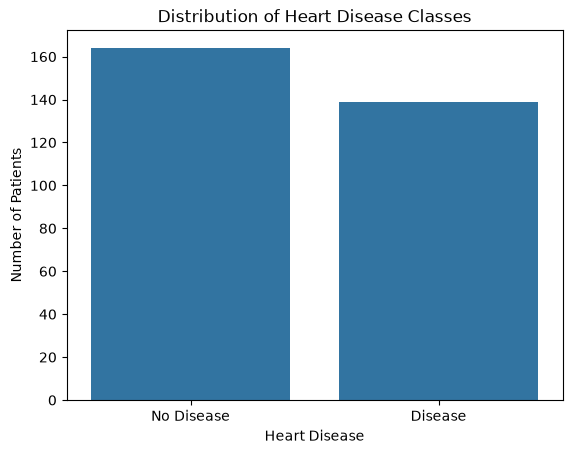

In [ ]:
#using sns 

eda = sns.barplot(x=y_binary.value_counts().index, y=y_binary.value_counts().values),plt.xticks([0, 1], 
["No Disease", "Disease"]),plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")
plt.title("Distribution of Heart Disease Classes")
plt.show()

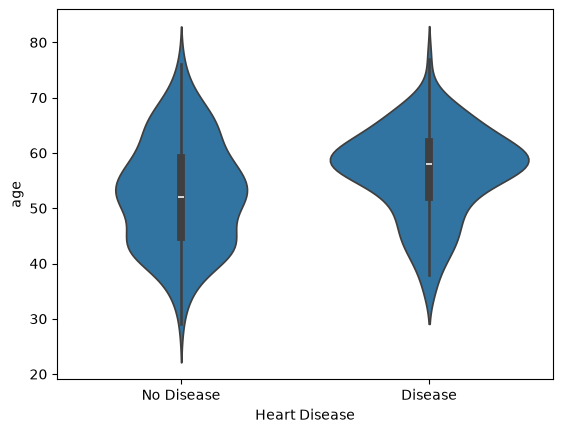

In [ ]:
age_diff_violin = sns.violinplot(x=y_binary, y=X['age']),plt.xticks([0, 1], ["No Disease", "Disease"]),plt.xlabel("Heart Disease")

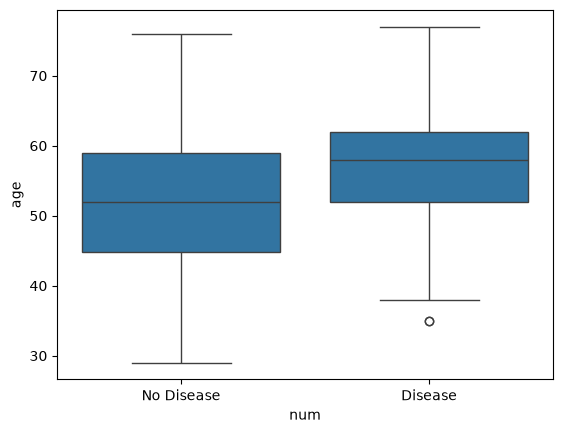

In [ ]:
age_diff_box= sns.boxplot(x = y_binary, y = X['age']),plt.xticks([0, 1], ["No Disease", "Disease"])

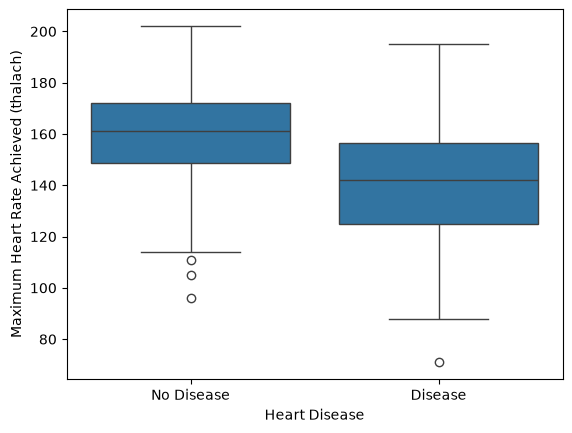

In [ ]:
#Compare maximum heart rate achieved (thalach) between the no-disease and disease groups.

thalach_diff_box = sns.boxplot(x = y_binary, y = X['thalach']), plt.xticks([0,1], ["No Disease", "Disease"]), plt.xlabel("Heart Disease"), plt.ylabel("Maximum Heart Rate Achieved (thalach)")


In [ ]:
# Find out how heart-disease prevalence changes across the different cp categories.
cross_tab = pd.crosstab(X['cp'], y_binary, normalize= 'index') * 100
cross_tab

num,0,1
cp,,
1,69.565217,30.434783
2,82.000000,18.000000
3,79.069767,20.930233
4,27.083333,72.916667


Text(0.5, 1.0, 'Heart Disease by Chest Pain Type')

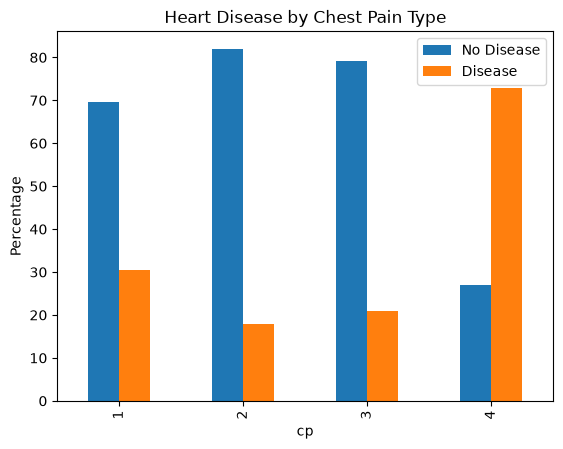

In [ ]:
cross_tab.columns = ['No Disease', 'Disease']
cross_tab.plot(kind = 'bar')
plt.ylabel("Percentage")
plt.title("Heart Disease by Chest Pain Type")

In [ ]:
exang_cross_tab = pd.crosstab(X['exang'], y_binary, normalize = 'index') *100 
exang_cross_tab

num,0,1
exang,,
0,69.117647,30.882353
1,23.232323,76.767677


Text(0.5, 1.0, 'Heart Disease by Exercise Induced Angina (exang)')

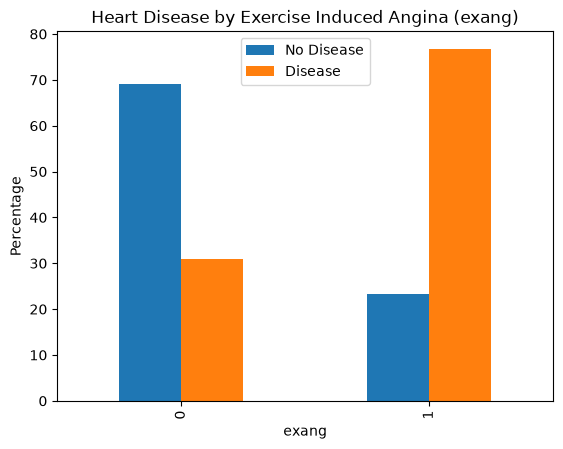

In [ ]:
exang_cross_tab.columns =['No Disease', 'Disease']
exang_cross_tab. plot(kind = 'bar')
plt.ylabel("Percentage")
plt.title("Heart Disease by Exercise Induced Angina (exang)")

In [ ]:
df_corr = X.copy()
df_corr['target'] = y_binary
df_corr.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [ ]:
df_corr.corr()["target"].sort_values(ascending = False)

target      1.000000
thal        0.522057
ca          0.460033
exang       0.431894
oldpeak     0.424510
cp          0.414446
slope       0.339213
sex         0.276816
age         0.223120
restecg     0.169202
trestbps    0.150825
chol        0.085164
fbs         0.025264
thalach    -0.417167
Name: target, dtype: float64

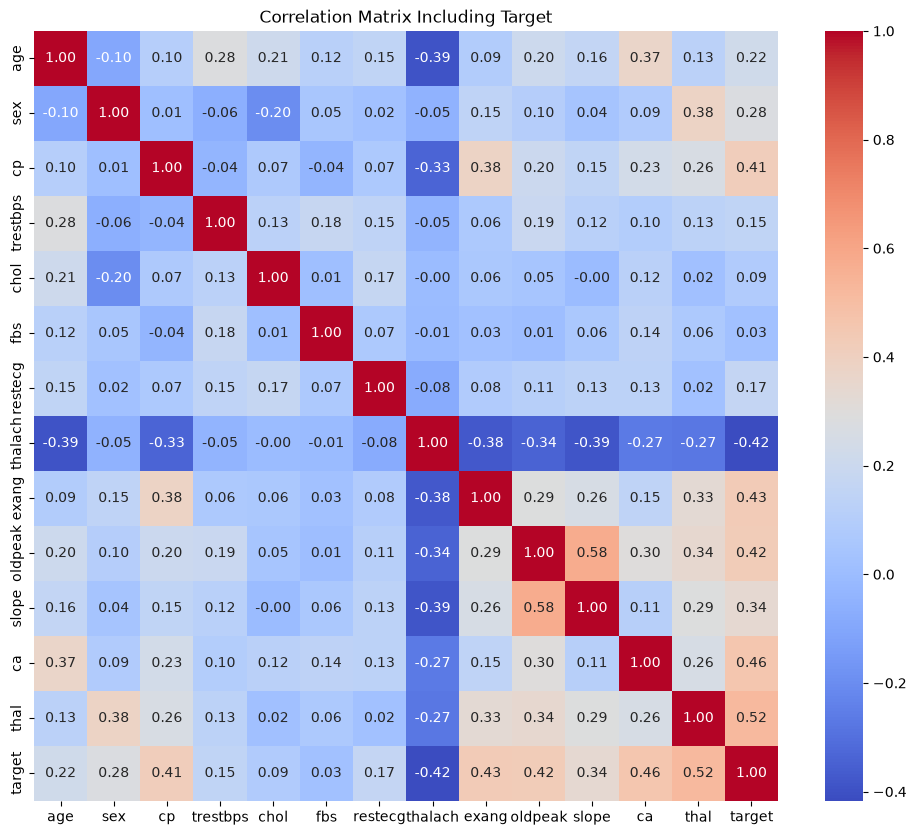

In [ ]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    df_corr.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix Including Target")
plt.show()

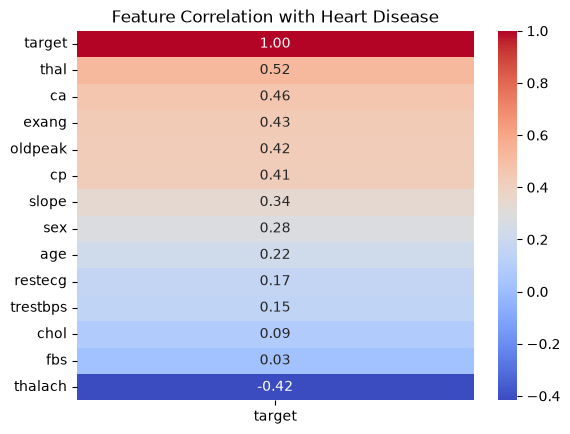

In [ ]:
target_corr = df_corr.corr()[["target"]].sort_values(
    by="target",
    ascending=False)

sns.heatmap(
    target_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm")

plt.title("Feature Correlation with Heart Disease")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary)

In [ ]:
y_train.value_counts(normalize=True)

num
0    0.541322
1    0.458678
Name: proportion, dtype: float64

In [ ]:
y_test.value_counts(normalize = True)

num
0    0.540984
1    0.459016
Name: proportion, dtype: float64

## Next model: Logistic Regression
features in X_train

        ↓

Logistic Regression

        ↓

probability of class 1

        ↓

prediction 0 or 1

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score,precision_score, recall_score, f1_score, roc_auc_score

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Why not fit_transform on the test set?
Because that would let the test set influence the preprocessing.
That’s called data leakage.
The test set should behave like totally unseen future data.

In [ ]:
model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [ ]:
y_pred = model.predict(X_test_scaled)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8688524590163934

For a heart-disease classifier, these two errors are very different:
- False positive: model says disease, but the patient actually has no disease
- False negative: model says no disease, but the patient actually has disease
That second one is especially important in a screening-style system, because missing a positive case is usually more concerning than flagging someone who turns out not to have disease.

In [ ]:
confusion_mat = confusion_matrix(y_test, y_pred)
confusion_mat

array([[27,  6],
       [ 2, 26]])

- 27 True Negatives (TN) → actually no disease, predicted no disease ✅
- 6 False Positives (FP) → actually no disease, predicted disease ❌
- 2 False Negatives (FN) → actually disease, predicted no disease ❌
- 26 True Positives (TP) → actually disease, predicted disease ✅
So out of the 28 patients who actually had heart disease, the model correctly found 26 of them and missed only 2.

## Next: precision and recall
Precision asks:

Of everyone the model predicted as having disease, how many actually had disease?

Recall asks:

Of everyone who actually had disease, how many did the model successfully detect?

In [ ]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(precision, recall, f1)

0.8125 0.9285714285714286 0.8666666666666667


- Precision = 81.25% → when the model predicts “disease,” it’s right about 81% of the time.
- Recall = 92.86% → it catches about 93% of the actual disease cases.
- F1 = 86.67% → a strong balance between precision and recall.
For this kind of classifier, that high recall is especially encouraging, because only 2 actual disease cases were missed in the test set.
The one thing to keep in mind is that this dataset is small, so we shouldn’t over-celebrate one split. With only 303 total rows, the result can move around depending on the train/test split.

In [ ]:
roc_auc_score = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])
print(roc_auc_score)

0.9512987012987013


Interpretation:
- 0.5 = basically random
- 1.0 = perfect separation
- 0.95 = the model is doing a very good job ranking disease cases above non-disease cases

## Random forest 

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [ ]:
rf_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [ ]:
rf_pred = rf_model.predict(X_test_scaled)
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
from sklearn.metrics import roc_auc_score

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

Accuracy: 0.8852459016393442
Precision: 0.8181818181818182
Recall: 0.9642857142857143
F1: 0.8852459016393442
ROC-AUC: 0.9512987012987013


So Random Forest wins slightly overall, mainly because of the higher recall and F1. Since our goal is to detect disease cases, that makes it a reasonable model to use for the first version of the app.

| Metric | Logistic Regression | Random Forest |
|---|---:|---:|
| Accuracy | 86.9% | **88.5%** |
| Precision | 81.3% | **81.8%** |
| Recall | 92.9% | **96.4%** |
| F1 | 86.7% | **88.5%** |
| ROC-AUC | **95.1%** | **95.1%** |

## Next: save the model

In [ ]:
import joblib

In [ ]:
joblib.dump(rf_model, "random_forest_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']